In [1]:
import numpy as np
import time
import pandas as pd

In [48]:
#Parte 1: Jacobiano
# Generar conos P y Q : matriz G (nxp), H (nxq)

n = 10

# P: cono octante positivo (nxn)
def identidad(n):
    matriz = np.zeros((n, n))
    np.fill_diagonal(matriz, 1)
    return matriz

# Q: cono de Schur (n x n-1)
def schur(n):
    matriz = np.zeros((n, n-1))  # La matriz de 2n columnas
    np.fill_diagonal(matriz, 1/np.sqrt(2))
    for i in range(1, n):
        matriz[i, i - 1] = -1/np.sqrt(2)   # Diagonal de y[i] con separación
    return matriz

G = identidad(n)
H = schur(n)

def initial_point(n):
    xi = np.random.uniform(0, 1, n)
    x0 = xi / np.linalg.norm(G @ xi)

    eta = np.random.uniform(0, 1, n-1)
    y0 = eta / np.linalg.norm(H @ eta)

    sigma0 = np.dot(G @ x0, H @ y0)
    rho0 = sigma0

    return x0, y0, sigma0, rho0

x0, y0, sigma0, rho0 = initial_point(n)
w0 = np.concatenate((x0, y0, [sigma0], [rho0]))

# Función Fischer-B (funcion de complementariedad)
def FB(x, y):
    FB = x + y -np.sqrt(x**2 + y**2)
    return FB

def F(x, y, sigma, rho):
    phi1 = FB(x, G.T @ H @ y - sigma * G.T @ G @ x)
    phi2 = FB(y, H.T @ G @ x - rho * H.T @ H @ y)
    norm_Gx = np.linalg.norm(G @ x)**2 - 1
    norm_Hy = np.linalg.norm(H @ y)**2 - 1
    F = np.concatenate((phi1.flatten(), phi2.flatten(), [norm_Gx], [norm_Hy]))
    return F

def norm_np(x, y):
    return np.sqrt(x**2 + y**2)
#derivada generalizada Fischer-Burmeister
def S(x, y):
    n = len(x)
    J_phi_2 = np.zeros((n, 2 * n))
    for i in range(n):
        norm = np.sqrt(x[i]**2 + y[i]**2 + 1e-8)
        J_phi_2[i, i] = 1 - (x[i] / norm)  # Derivada respecto a x
        J_phi_2[i, n + i] = 1 - (y[i] / norm)  # Derivada respecto a y
    return J_phi_2


def calcular_bloques_A(x, y, sigma):
    p = len(x)
    q = len(y)
    mat1 = S(x, G.T @ H @ y - sigma * G.T @ G @ x)
    mat2 = np.block([
        [np.eye(p), np.zeros((p, q))],
        [-sigma * G.T @ G, G.T @ H]
    ])
    A = mat1 @ mat2
    return A

def calcular_bloques_B(x, y, rho):
    p = len(x)
    q = len(y)
    mat1 = S(y, H.T @ G @ x - rho * H.T @ H @ y)
    mat2 = np.block([
        [np.zeros((q, p)), np.eye(q)],
        [H.T @ G, -rho * H.T @ H]
    ])
    B = mat1 @ mat2
    return B

# Jacobiano JF
def JF(x, y, sigma, rho):
    A = calcular_bloques_A(x, y, sigma)
    B = calcular_bloques_B(x, y, rho)
    p = len(x)
    q = len(y)
    # matriz Jacobiana completa
    jacobiano_completo = np.block([
        [A, -G.T @ G @ x[:, np.newaxis], np.zeros((p, 1))],
        [B, np.zeros((q, 1)), -H.T @ H @ y[:, np.newaxis]],
        [2 * (G.T @ G @ x)[np.newaxis, :], np.zeros((1, q)), np.zeros((1, 1)), np.zeros((1, 1))],
        [np.zeros((1, p)), 2 * (H.T @ H @ y)[np.newaxis, :], np.zeros((1, 1)), np.zeros((1, 1))]
    ])
    return jacobiano_completo

# Test Jacobiano
Jacobiano = JF(x0, y0, sigma0, rho0)
print("Jacobiano:",Jacobiano)
print("######")
print("Punto inicial:",w0)


Jacobiano: [[ 7.15331624e-01  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  3.17246519e-02  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00 -1.40040273e-01
   0.00000000e+00]
 [ 0.00000000e+00  4.23800147e-01  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00 -9.70414091e-01  9.70414091e-01
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00 -4.94150306e-01
   0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  9.39871671e-01  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00 -1.29957678e-03
   1.29957678e-03  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.000000

In [49]:
#Parte 2 Newton-Semismoth

def newton_raphson(F, JF, w0, tol=1e-6, max_iter=1000):
    w = w0
    iter = 0
    for _ in range(max_iter):
        iter = iter + 1
        x, y, sigma, rho = w[:n], w[n:2*n-1], w[2*n-1], w[2*n]
        F_w = F(x, y, sigma, rho)
        J = JF(x, y, sigma, rho)

        try:
            delta_w = np.linalg.solve(J, -F_w)
            w += delta_w
            if np.linalg.norm(delta_w) < tol:
                break
        except np.linalg.LinAlgError as e:
            print(f"Error al resolver el sistema: {e}")
            return None
    return w, iter

# Solución
w0 = np.concatenate((x0, y0, [sigma0], [rho0]))
w_final, iter = newton_raphson(F, JF, w0)

if w_final is not None:
    print("Cero de F encontrado:")
    print(w_final)
else:
    print("No se pudo encontrar una solución.")

# Umbral para considerar un valor "casi cero"
umbral_casi_cero = 1e-10

# Redondeamos y eliminamos los valores pequeños
cero_simplificado = np.round(np.where(np.abs(w_final) < umbral_casi_cero, 0, w_final), 4)

print("cero de F simplificado:", cero_simplificado)

x, y = w_final[:n], w_final[n:2*n-1]
G_x , H_y = G @ x , H @ y
print("#############")
producto_interno = np.dot(G_x,H_y)

angulo_critico = np.arccos(producto_interno)
print(f"Ángulo critico entre los conos G y H: {angulo_critico/np.pi} pi")
print(f"Ángulo critico entre los conos G y H en grados: {np.degrees(angulo_critico)}")

# Función para encontrar las posiciones de las entradas no nulas o generadores, analiza cada componente no nula
def generadores_activos(v):
    return np.where(np.abs(v) > 1e-10)[0]

G_x = np.round(np.where(np.abs(G_x) < umbral_casi_cero, 0, G_x), 4) #simplificamos los vectores para identificar bien los generadores
H_y = np.round(np.where(np.abs(H_y) < umbral_casi_cero, 0, H_y), 4)

activos_G_x = generadores_activos(G_x)
activos_H_y = generadores_activos(H_y)


print(f"Generadores activos en G*x = u: {G_x} (índices): {activos_G_x}")
print(f"Generadores activos en H(y) = v: {H_y} (índices): {activos_H_y}")
print(x)
print(y)

Cero de F encontrado:
[ 1.96552433e-17  9.99999998e-01 -1.11448975e-06 -3.14744429e-06
  5.23765435e-05 -2.46514047e-06 -3.93816028e-06  4.15606426e-05
 -2.71208186e-07  1.01273621e-07  9.99999998e-01  7.73340320e-12
  2.55425248e-05  6.04269364e-05 -1.75409931e-06  2.06071183e-05
  4.70549208e-05 -1.87701026e-06 -6.85113368e-08 -7.07106781e-01
 -7.07106781e-01]
cero de F simplificado: [ 0.000e+00  1.000e+00 -0.000e+00 -0.000e+00  1.000e-04 -0.000e+00
 -0.000e+00  0.000e+00 -0.000e+00  0.000e+00  1.000e+00  0.000e+00
  0.000e+00  1.000e-04 -0.000e+00  0.000e+00  0.000e+00 -0.000e+00
 -0.000e+00 -7.071e-01 -7.071e-01]
#############
Ángulo critico entre los conos G y H: 0.7500000003866483 pi
Ángulo critico entre los conos G y H en grados: 135.0000000695967
Generadores activos en G*x = u: [ 0.e+00  1.e+00 -0.e+00 -0.e+00  1.e-04 -0.e+00 -0.e+00  0.e+00 -0.e+00
  0.e+00] (índices): [1 4]
Generadores activos en H(y) = v: [ 0.7071 -0.7071  0.      0.     -0.      0.      0.     -0.      0.
 


Resumen del Testeo:
                             Estado  Veces  Tiempo promedio CPU
0                          Converge    717               0.2166
1                       No converge    283               0.2166
2  Mal condicionado (No invertible)      0               0.2166

Resultados Detallados de Cada Punto:
     Punto       Estado  CPU Time (s)  Ángulo Crítico (pi)  Ángulo Crítico (°)
0        1     Converge      0.008415             0.897584          161.565051
1        2  No converge      0.586174                  NaN                 NaN
2        3  No converge      0.871885                  NaN                 NaN
3        4  No converge      1.249505                  NaN                 NaN
4        5     Converge      0.009857             0.750000          135.000000
..     ...          ...           ...                  ...                 ...
995    996     Converge      0.010560             0.897584          161.565051
996    997  No converge      0.593989                

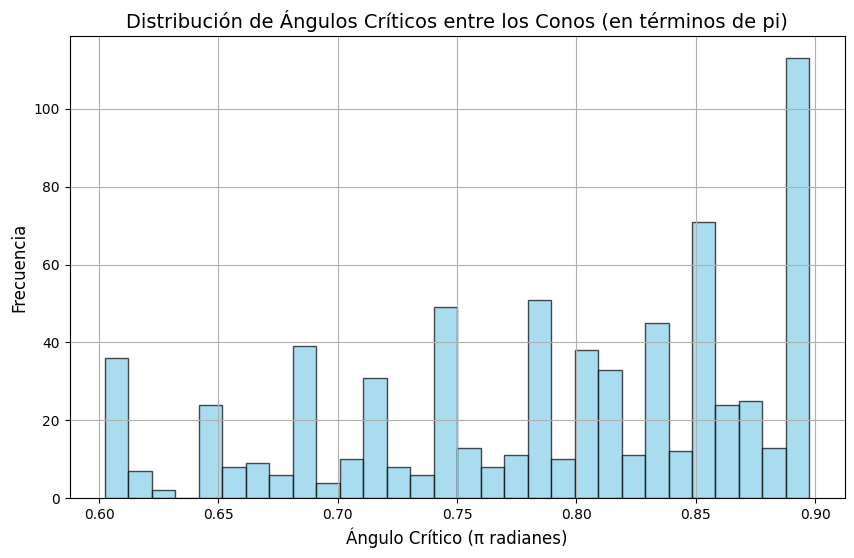


Porcentajes de Ángulos Críticos en los Intervalos:
  Intervalo (π radianes)  Porcentaje (%)
0           [0.0π, 0.1π)             0.0
1           [0.1π, 0.2π)             0.0
2           [0.2π, 0.3π)             0.0
3           [0.3π, 0.4π)             0.0
4           [0.4π, 0.5π)             0.0
5           [0.5π, 0.6π)             0.0
6           [0.6π, 0.7π)            13.5
7           [0.7π, 0.8π)            19.7
8           [0.8π, 0.9π)            38.5
9           [0.9π, 1.0π)             0.0


In [50]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

#Parte 3, testeo del algoritmo

num_puntos = 1000

def test_angulo_critico(num_puntos):
    resultados_detallados = []
    resultados_resumen = {
        "Converge": 0,
        "No converge": 0,
        "Mal condicionado (No invertible)": 0
    }

    # Lista para almacenar los tiempos de CPU y los ángulos críticos
    tiempos_cpu = []
    angulos_criticos = []

    for i in range(num_puntos):
        x0, y0, sigma0, rho0 = initial_point(n)
        w0 = np.concatenate((x0, y0, [sigma0], [rho0]))

        # Tiempo de ejecución
        start_time = time.time()

        w_final, iter = newton_raphson(F, JF, w0)


        tiempo_cpu = time.time() - start_time
        tiempos_cpu.append(tiempo_cpu)

        # Estado inicial
        estado = ""
        angulo_critico_radianes = None
        angulo_critico_grados = None

        if iter == 10**3:
            # (divergencia)
            estado = "No converge"
            resultados_resumen["No converge"] += 1
        else:
            # Si el método converge
            x, y = w_final[:n], w_final[n:2*n-1]
            G_x, H_y = G @ x, H @ y
            producto_interno = np.dot(G_x, H_y)

            # Calcular el ángulo crítico
            try:
                angulo_critico_radianes = np.arccos(producto_interno)
                angulo_critico_grados = np.degrees(angulo_critico_radianes)
                estado = "Converge"
                resultados_resumen["Converge"] += 1
                angulos_criticos.append(angulo_critico_radianes / np.pi)
            except ValueError:
                estado = "Mal condicionado (No invertible)"
                resultados_resumen["Mal condicionado (No invertible)"] += 1

        resultados_detallados.append({
            "Punto": i + 1,
            "Estado": estado,
            "CPU Time (s)": round(tiempo_cpu, 6),
            "Ángulo Crítico (pi)": round(angulo_critico_radianes / np.pi, 6) if angulo_critico_radianes is not None else np.nan,
            "Ángulo Crítico (°)": round(angulo_critico_grados, 6) if angulo_critico_grados is not None else np.nan
        })

    df_resultados_detallados = pd.DataFrame(resultados_detallados)

    # DataFrame del resumen
    tiempo_promedio_cpu = np.mean(tiempos_cpu)
    df_resultados_resumen = pd.DataFrame(list(resultados_resumen.items()), columns=["Estado", "Veces"])
    df_resultados_resumen["Tiempo promedio CPU"] = round(tiempo_promedio_cpu, 6)

    print("\nResumen del Testeo:")
    print(df_resultados_resumen)

    print("\nResultados Detallados de Cada Punto:")
    print(df_resultados_detallados)

    # Crear la gráfica de barras para los ángulos críticos
    plot_angulo_critico(angulos_criticos)

    return df_resultados_resumen, df_resultados_detallados, angulos_criticos

# Crear la gráfica de barras de los ángulos críticos
def plot_angulo_critico(angulos_criticos):
    # Graficar los ángulos críticos en términos de pi
    plt.figure(figsize=(10, 6))
    plt.hist(angulos_criticos, bins=30, edgecolor='black', color='skyblue', alpha=0.7)
    plt.title('Distribución de Ángulos Críticos entre los Conos (en términos de pi)', fontsize=14)
    plt.xlabel('Ángulo Crítico (π radianes)', fontsize=12)
    plt.ylabel('Frecuencia', fontsize=12)
    plt.grid(True)
    plt.show()

# Intervalos y sus porcentajes
def calcular_porcentaje_intervalos(angulos_criticos, num_puntos=10):
    intervalos = [
        "[0.0π, 0.1π)", "[0.1π, 0.2π)", "[0.2π, 0.3π)", "[0.3π, 0.4π)",
        "[0.4π, 0.5π)", "[0.5π, 0.6π)", "[0.6π, 0.7π)", "[0.7π, 0.8π)",
        "[0.8π, 0.9π)", "[0.9π, 1.0π)"
    ]

    limites_intervalos = np.arange(0.0, 1.1, 0.1)

    # Contar cuántos ángulos caen dentro de cada intervalo
    conteo = np.histogram(angulos_criticos, bins=limites_intervalos)[0]

    # Calcular el porcentaje para cada intervalo
    porcentajes = (conteo / num_puntos) * 100

    # DataFrame con los intervalos y los porcentajes
    df_intervalos = pd.DataFrame({
        "Intervalo (π radianes)": intervalos,
        "Porcentaje (%)": porcentajes
    })

    return df_intervalos

df_resultados_resumen, df_resultados_detallados, angulos_criticos = test_angulo_critico(num_puntos)
df_intervalos_porcentaje = calcular_porcentaje_intervalos(angulos_criticos, num_puntos)

# DataFrame intervalos y porcentajes
print("\nPorcentajes de Ángulos Críticos en los Intervalos:")
print(df_intervalos_porcentaje)

In [31]:
# Extra: Cálculo de los ángulos

import numpy as np

def generar_puntos_iniciales(n, num_puntos=100):
    puntos_iniciales = []
    for _ in range(num_puntos):
        x0, y0, sigma0, rho0 = initial_point(n)
        w0 = np.concatenate((x0, y0, [sigma0], [rho0]))
        puntos_iniciales.append(w0)
    return puntos_iniciales

# Generamos 100 puntos iniciales
num_puntos = 100
puntos_iniciales = generar_puntos_iniciales(n, num_puntos)
resultados = []

for i, w0 in enumerate(puntos_iniciales):
    w_final, iter = newton_raphson(F, JF, w0)

    if w_final is not None:
        x, y = w_final[:n], w_final[n:2*n-1]
        G_x, H_y = G @ x, H @ y
        producto_interno = np.dot(G_x, H_y)
        angulo_critico = np.arccos(producto_interno)
        angulo_critico_pi = angulo_critico / np.pi
        angulo_critico_grados = np.degrees(angulo_critico)

        # Almacenamos los resultados
        resultados.append({
            'punto_inicial': w0,
            'punto_final': w_final,
            'iteraciones': iter,
            'angulo_critico_pi': angulo_critico_pi,
            'angulo_critico_grados': angulo_critico_grados,
            'generadores_G': G_x,
            'generadores_H': H_y
        })
        print(f"\nResultado {i+1}:")
        print(f"Ángulo crítico entre los conos G y H: {angulo_critico_pi} pi")
        print(f"Ángulo crítico entre los conos G y H en grados: {angulo_critico_grados}")
        print(f"Punto final: {w_final}")
        print(f"Iteraciones: {iter}")
        print(f"Generadores activos en G*x = u: {G_x}")
        print(f"Generadores activos en H(y) = v: {H_y}")
    else:
        print(f"\nResultado {i+1}: No se pudo encontrar una solución.")


Se truncaron las últimas líneas 5000 del resultado de transmisión.
Resultado 12:
Ángulo crítico entre los conos G y H: 0.948809251086605 pi
Ángulo crítico entre los conos G y H en grados: 170.7856651955889
Punto final: [ 5.00105076e-19  9.02128722e-19  6.46489524e-19 -3.28053905e-19
  1.24945459e-18  3.44110615e-19  6.94869256e-19 -1.76150199e-18
 -4.48224363e-19 -5.20038494e-19 -1.52851746e-18 -1.47856441e-18
  8.76427423e-19 -4.89627968e-19  5.86590314e-19 -3.30588075e-19
 -8.56276003e-19 -3.64837214e-19 -1.91274334e-21 -1.18148331e-18
  1.31150049e-19 -5.06786283e-19  1.14535912e-18  3.36802601e-19
 -1.15338916e-18 -9.31410389e-19 -1.69741096e-18 -3.18837128e-19
  1.04089830e-18  2.92651817e-19  3.44421093e-20 -1.18591728e-19
  9.79330219e-19  1.10658064e-18  1.26337916e-18  1.16252191e-18
  1.24874007e-18 -1.63557253e-18  1.00000000e+00  2.27074861e-07
  1.86834898e-07  9.32621630e-08 -7.27058138e-08  2.97915458e-08
  3.76288926e-08  6.73788129e-08  6.95379743e-08  5.09953677e-08
 